## AI IMPACT ON JOBS IN **2030**  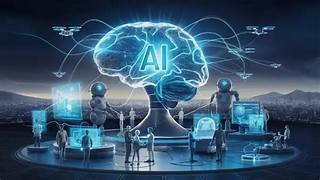

---



# Full Pipeline: Preprocessing, Feature Selection, Classification, Comparison, Visualization, Metrics, Prediction

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

# 1. LOAD DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AI_Impact_on_Jobs_2030 (1).csv to AI_Impact_on_Jobs_2030 (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("AI_Impact_on_Jobs_2030 (1).csv")

df.head()

,Job_Title,Job_Title.1,Job_Title.2,Job_Title.3,Job_Title.4,Job_Title.5,Job_Title.6,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


##  2.Initial Look at Data

In [ ]:
print("🔍 Shape of dataset:", df.shape)
df.head()

🔍 Shape of dataset: (3000, 18)


,Job_Title,Job_Title.1,Job_Title.2,Job_Title.3,Job_Title.4,Job_Title.5,Job_Title.6,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


# RENAMING

In [ ]:
df.columns = [
    "Job_Title", "Salary", "Experience", "Education",
    "Automation_Risk", "AI_Exposure", "Job_Growth",
    "Risk_Category",
    "Programming",
    "Data_Analysis",
    "Communication",
    "Problem_Solving",
    "Creativity",
    "Leadership",
    "Technical_Knowledge",
    "Critical_Thinking",
    "Customer_Service",
    "Adaptability"
]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Salary               3000 non-null   int64  
 1   Experience           3000 non-null   int64  
 2   Education            3000 non-null   int64  
 3   Automation_Risk      3000 non-null   float64
 4   AI_Exposure          3000 non-null   float64
 5   Job_Growth           3000 non-null   float64
 6   Risk_Category        3000 non-null   int64  
 7   Programming          3000 non-null   float64
 8   Data_Analysis        3000 non-null   float64
 9   Communication        3000 non-null   float64
 10  Problem_Solving      3000 non-null   float64
 11  Creativity           3000 non-null   float64
 12  Leadership           3000 non-null   float64
 13  Technical_Knowledge  3000 non-null   float64
 14  Critical_Thinking    3000 non-null   float64
 15  Customer_Service     3000 non-null   f

# **Data Preprocessing**


# 1. Handle Missing Values

In [ ]:
print("\nBefore missing value check:")
print(df.isnull().sum())

df = df.dropna()  # simple drop
print("\nAfter missing value check:")
print(df.isnull().sum())


Before missing value check:
Job_Title              0
Salary                 0
Experience             0
Education              0
Automation_Risk        0
AI_Exposure            0
Job_Growth             0
Risk_Category          0
Programming            0
Data_Analysis          0
Communication          0
Problem_Solving        0
Creativity             0
Leadership             0
Technical_Knowledge    0
Critical_Thinking      0
Customer_Service       0
Adaptability           0
dtype: int64

After missing value check:
Job_Title              0
Salary                 0
Experience             0
Education              0
Automation_Risk        0
AI_Exposure            0
Job_Growth             0
Risk_Category          0
Programming            0
Data_Analysis          0
Communication          0
Problem_Solving        0
Creativity             0
Leadership             0
Technical_Knowledge    0
Critical_Thinking      0
Customer_Service       0
Adaptability           0
dtype: int64


# 2.Encode Categorical Columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_education = LabelEncoder()
le_risk = LabelEncoder()

df["Education"] = le_education.fit_transform(df["Education"])
df["Risk_Category"] = le_risk.fit_transform(df["Risk_Category"])

# 3.Drop Job Title

In [ ]:
df = df.drop("Job_Title", axis=1)

# **Visualize**

# 1.Risk Category Distribution

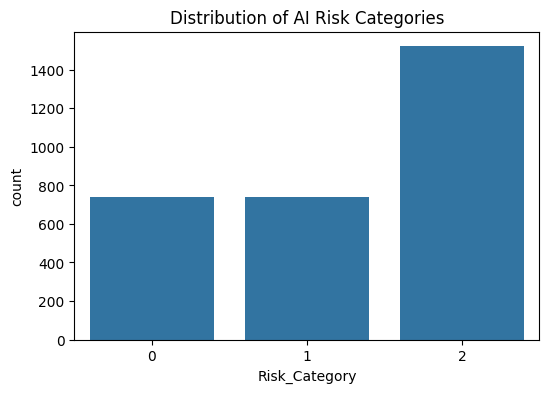

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Category", data=df)
plt.title("Distribution of AI Risk Categories")
plt.show()

# 2.Salary vs Risk Category

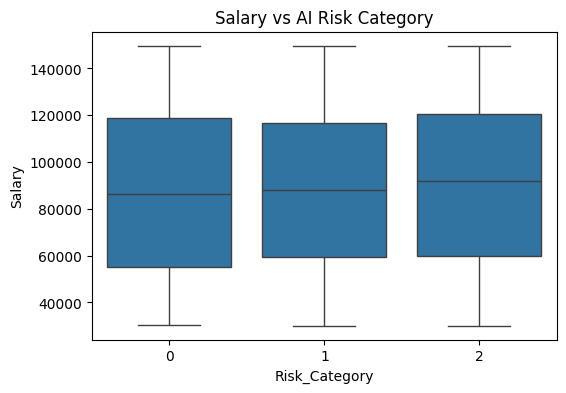

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Risk_Category", y="Salary", data=df)
plt.title("Salary vs AI Risk Category")
plt.show()

# 3.Correlation Heatmap

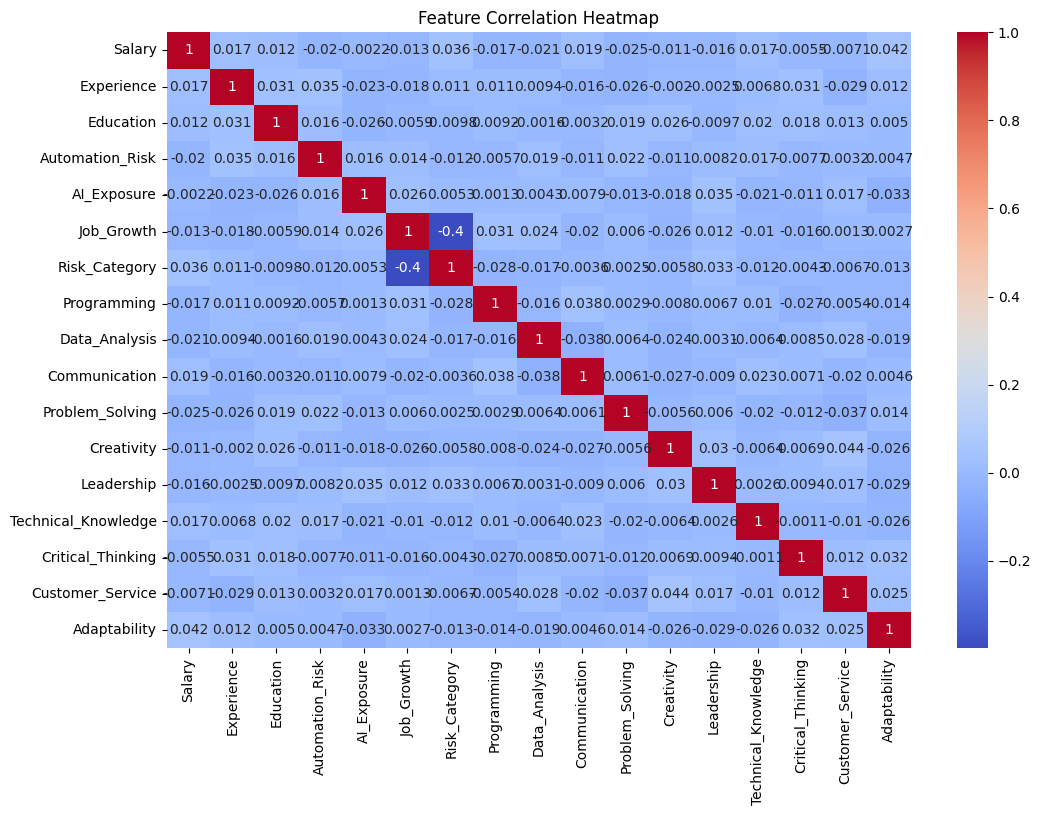

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# **Feature Selection**

# 1.Separate Features & Target

In [ ]:
X = df.drop("Risk_Category", axis=1)
y = df["Risk_Category"]

# 2.Select Top 8 Important Features

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Salary', 'AI_Exposure', 'Job_Growth', 'Programming', 'Data_Analysis',
       'Creativity', 'Leadership', 'Technical_Knowledge'],
      dtype='object')


# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# **Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models

# 1.Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9866666666666667
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       167
           1       0.99      0.97      0.98       149
           2       0.98      1.00      0.99       284

    accuracy                           0.99       600
   macro avg       0.99      0.98      0.99       600
weighted avg       0.99      0.99      0.99       600



# 2.Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       167
           1       1.00      1.00      1.00       149
           2       1.00      1.00      1.00       284

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



# 3.SVM

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       167
           1       0.99      0.97      0.98       149
           2       0.95      0.98      0.96       284

    accuracy                           0.96       600
   macro avg       0.97      0.96      0.97       600
weighted avg       0.97      0.96      0.96       600



# Model Comparison

In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

print("Model Comparison:")
for model, acc in results.items():
    print(model, ":", acc)

Model Comparison:
Logistic Regression : 0.9866666666666667
Random Forest : 1.0
SVM : 0.965


# Confusion Matrix

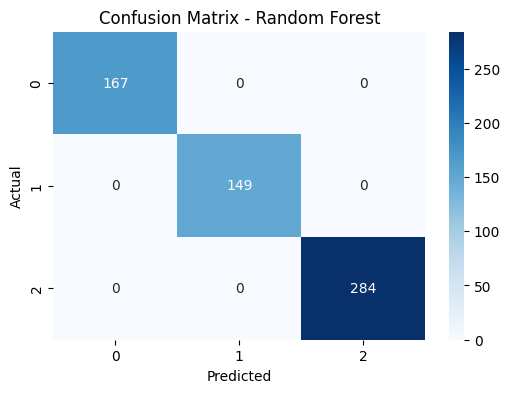

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance

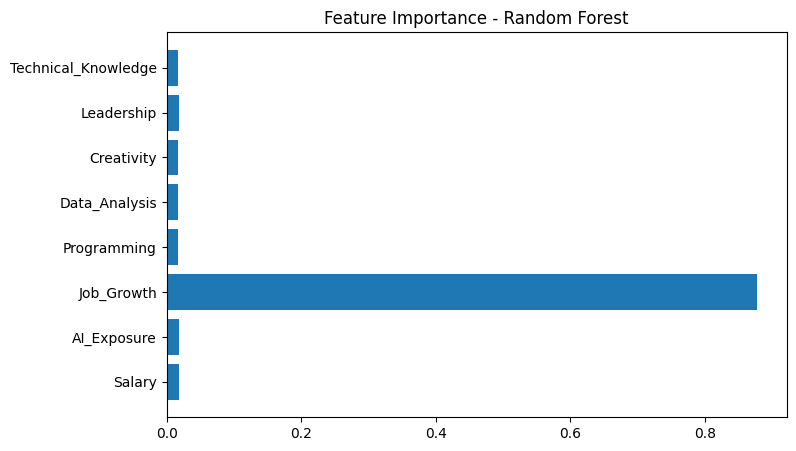

In [ ]:
importances = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(selected_features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

# Predict on Test Data

In [ ]:
# Example new job data
new_job = [[90000, 5, 2, 0.4, 1.2, 0.5,
            0.6,0.5,0.7,0.3,0.4,0.8,0.6,0.2,0.9,0.4]]

# Apply feature selection
new_job_selected = selector.transform(new_job)

# Scale
new_job_scaled = scaler.transform(new_job_selected)

# Predict using best model (Random Forest)
prediction = rf.predict(new_job_scaled)

print("Predicted Risk Category:",
      le_risk.inverse_transform(prediction))

Predicted Risk Category: [2]
